# Spatial Hotspot Analysis using KDE & Gaussian Mixture Models

This notebook identifies **spatial hotspots** of taxi activity in Chicago, using two complementary density methods on the pickup and dropoff coordinates:

1. **Kernel Density Estimation (KDE)**, a smooth, non-parametric density surface showing *where* activity concentrates.
2. **Gaussian Mixture Models (GMM)**, a parametric model that summarises the same density as a handful of Gaussian *components*; each component's mean is a hotspot centre and its weight is the share of trips it captures. The number of components is chosen by **AIC**, and because the mixture is a probabilistic *soft-clustering* model, `predict_proba` yields a membership probability of every location for each hotspot — contrasted with a hard **k-means** partition as a baseline.

Both methods run for **pickups** and **dropoffs** separately (Pickup = left, Dropoff = right).

## Important caveat: coordinates are area centroids, not raw GPS

As established in `data_exploration.ipynb`, `lat`/`lon` are **centroids** of a census tract or community area, so the data contains only a few hundred *distinct* coordinates, each repeated for many trips. Two consequences shape the method below:

- **KDE** is fitted on the *unique* coordinates with `sample_weight` set to the trip count at each, this is both efficient and weights density by trip volume rather than by the number of distinct centroids.
- **GMM** has no sample-weighting, so we draw a volume-proportional subsample and add a small spatial **jitter** (≈ the centroid spacing); Section 2 explains why this is necessary and what the jitter means.

Distances/bandwidths are expressed in **degrees** (at Chicago's latitude, 0.01° ≈ 0.85 km E–W and ≈ 1.11 km N–S); the mild anisotropy is acceptable for locating hotspots.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import geopandas
import shapely
from sklearn.cluster import KMeans
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture

RANDOM_STATE = 42

## Load data

Only the pickup/dropoff coordinates are needed. We keep both raw points and, for KDE, a *weighted-unique* representation: the distinct centroids with the number of trips at each.

In [2]:
_COORD_COLS = ["pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon"]

df = pl.read_parquet("../data/02_merged_data_sample_10pct.parquet", columns=_COORD_COLS).to_pandas()
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


def coords(side):
    """Raw (lon, lat) array for one side ('pickup'/'dropoff'), NaNs dropped."""
    sub = df[[f"{side}_lon", f"{side}_lat"]].dropna()
    return sub.to_numpy()


def weighted_unique(side):
    """Distinct (lon, lat) centroids and the trip count (weight) at each."""
    sub = df[[f"{side}_lon", f"{side}_lat"]].dropna()
    g = sub.groupby([f"{side}_lon", f"{side}_lat"]).size().reset_index(name="w")
    return g[[f"{side}_lon", f"{side}_lat"]].to_numpy(), g["w"].to_numpy(dtype="float64")


for side in ("pickup", "dropoff"):
    xy, w = weighted_unique(side)
    print(f"{side:>7}: {int(w.sum()):>10,} trips across {len(xy):>4} distinct centroids")

Shape: 1,349,173 rows x 4 columns
 pickup:  1,349,173 trips across  386 distinct centroids
dropoff:  1,255,071 trips across  496 distinct centroids


## Community-area boundaries & city extent

The 77 community areas are used purely as a backdrop and, later, to *name* each hotspot. Their union is the city polygon, used to mask the KDE grid (so density is only drawn over Chicago) and to set the map extent.

In [3]:
communities_gdf = geopandas.read_file("../data/chicago_community_boundaries.json")
communities_gdf["area_number"] = communities_gdf["area_numbe"].astype(int)
communities_gdf["community"] = communities_gdf["community"].str.title()
communities_gdf = communities_gdf[["area_number", "community", "geometry"]].set_crs("EPSG:4326")

city_poly = communities_gdf.union_all()
XMIN, YMIN, XMAX, YMAX = communities_gdf.total_bounds
print(f"{len(communities_gdf)} community areas; "
      f"extent lon [{XMIN:.3f}, {XMAX:.3f}], lat [{YMIN:.3f}, {YMAX:.3f}]")

77 community areas; extent lon [-87.940, -87.524], lat [41.645, 42.023]


## 1. Kernel Density Estimation

A Gaussian KDE is fitted on the **weighted-unique** centroids of each side, then evaluated on a regular grid that is masked to the city polygon. The result is a smooth surface whose value is proportional to trip density; the brightest regions are the hotspots.

`BANDWIDTH` (in degrees) controls smoothing: too small and the surface breaks into one blob per centroid, too large and distinct hotspots merge. ≈ 0.006° (≈ 600 m) is a reasonable compromise given the centroid spacing (it can be adjusted).

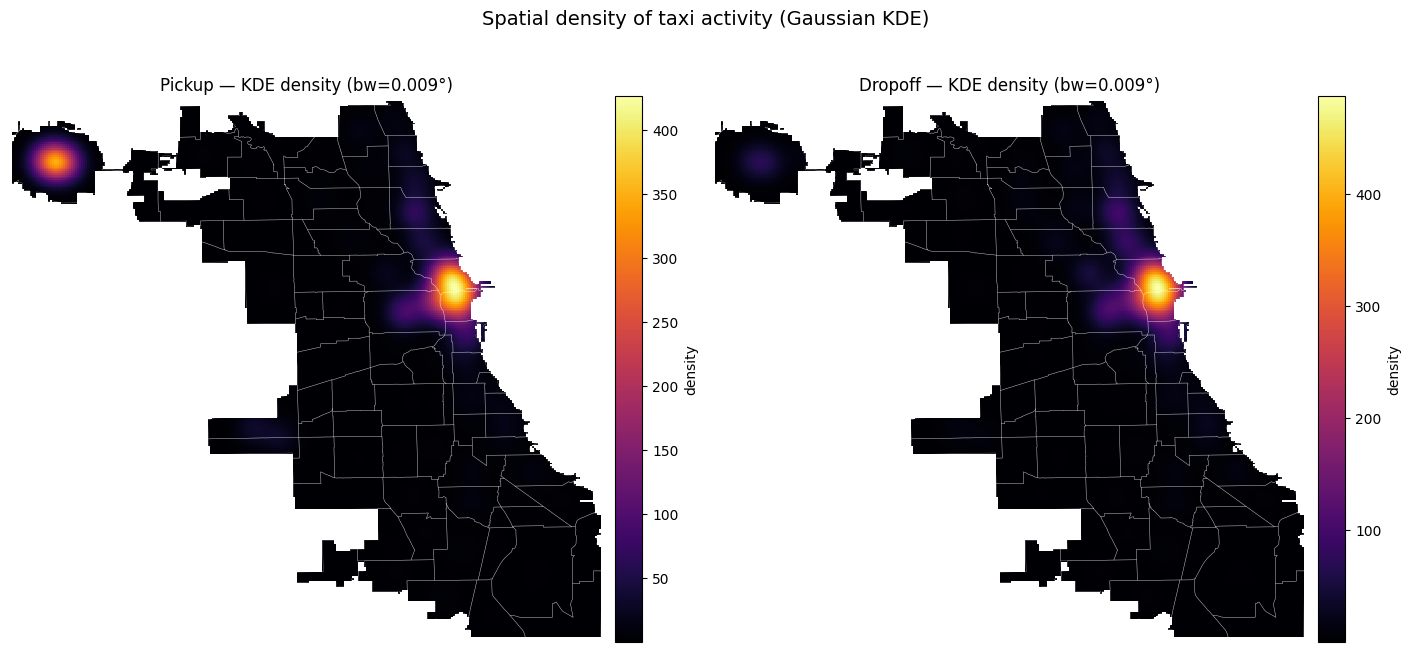

In [8]:
BANDWIDTH = 0.009   # degrees (~600 m); smoothing scale of the KDE
GRID_SIZE = 300     # grid resolution per axis for evaluating the density

# Grid over the city extent, masked to the actual Chicago polygon.
_xs = np.linspace(XMIN, XMAX, GRID_SIZE)
_ys = np.linspace(YMIN, YMAX, GRID_SIZE)
_XX, _YY = np.meshgrid(_xs, _ys)
_grid = np.column_stack([_XX.ravel(), _YY.ravel()])
_inside = shapely.contains_xy(city_poly, _grid[:, 0], _grid[:, 1])


def kde_surface(side, bandwidth=BANDWIDTH):
    """Volume-weighted Gaussian KDE evaluated on the masked city grid."""
    xy, w = weighted_unique(side)
    kde = KernelDensity(bandwidth=bandwidth, kernel="gaussian").fit(xy, sample_weight=w)
    dens = np.full(_grid.shape[0], np.nan)
    dens[_inside] = np.exp(kde.score_samples(_grid[_inside]))
    return dens.reshape(_XX.shape)


fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, side in zip(axes, ("pickup", "dropoff")):
    Z = kde_surface(side)
    mesh = ax.pcolormesh(_XX, _YY, np.ma.masked_invalid(Z), cmap="inferno", shading="auto")
    communities_gdf.boundary.plot(ax=ax, color="white", linewidth=0.3, alpha=0.5)
    fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.02, label="density")
    ax.set_title(f"{side.title()} — KDE density (bw={BANDWIDTH}°)")
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.suptitle("Spatial density of taxi activity (Gaussian KDE)", fontsize=14)
plt.show()

## 2. Gaussian Mixture Models

A GMM describes the point cloud as a sum of `K` 2-D Gaussians. Each component is a candidate hotspot: its **mean** is the centre, its **covariance** the spread/orientation, and its **weight** the fraction of trips it explains.

### Building the fitting sample — why the jitter is necessary

`GaussianMixture` cannot take sample weights, so trip volume has to enter through **resampling**: we draw a volume-proportional subsample of the centroids, so high-volume areas contribute proportionally many points. That alone is not enough, though. All trips of an area share its *exact* centroid coordinate, and a full-covariance GMM maximises its likelihood by collapsing a component onto such a point mass: the covariance shrinks until it hits sklearn's regularisation floor (`reg_covar`), and the fitted "extent" of that hotspot is then a numerical constant rather than an estimate. (Dropping the jitter here produces spike components at that floor holding ~40% of the mixture mass, including the Loop and O'Hare.)

The **jitter** — Gaussian noise of roughly the centroid spacing — fixes this, and it is more than a numerical trick. The raw data was *snapped to centroids* in the first place: each centroid stands in for trips that really started somewhere inside its tract or community area. Jittering approximately *un-does* that coarsening by smearing the trip mass back over the area the centroid represents. Formally, resampling ∝ trip count plus Gaussian jitter is exactly **sampling from the trip-weighted Gaussian KDE of Section 1** (with bandwidth = the jitter scale), so the GMM is fitted to draws from the same density surface visualised above and summarises it with `K` Gaussians.

### Choosing K

Following the workshop, we fit a GMM for each `K` and pick the one minimising the **AIC** (Akaike Information Criterion), which rewards likelihood and penalises extra parameters. One data-driven caveat: because the underlying points are only a few hundred discrete centroid clouds, the criterion keeps creeping downward as `K` grows (each additional Gaussian can latch onto yet another centroid), so we cap the search at `K = 15` — the curve flattens well before that, and beyond it extra components mostly split existing hotspots rather than reveal new ones.

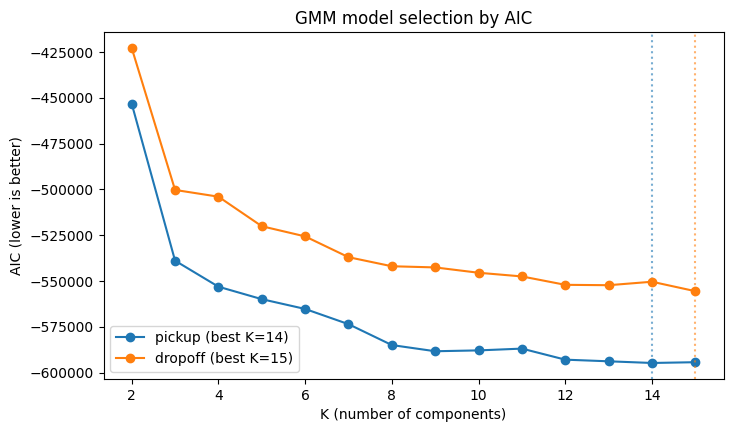

Selected K: {'pickup': 14, 'dropoff': 15}


In [5]:
SUBSAMPLE = 60_000   # points drawn (with replacement) for GMM fitting
JITTER = 0.004       # degrees of Gaussian noise added to spread centroids
K_RANGE = range(2, 16)

_rng = np.random.default_rng(RANDOM_STATE)


def gmm_sample(side, n=SUBSAMPLE, jitter=JITTER):
    """Volume-proportional, jittered point sample for GMM fitting."""
    xy, w = weighted_unique(side)
    idx = _rng.choice(len(xy), size=n, replace=True, p=w / w.sum())
    return xy[idx] + _rng.normal(0.0, jitter, size=(n, 2))


def select_k(sample, k_range=K_RANGE):
    """Fit a GMM for each K and return (aics, best_k), as in the workshop."""
    aics = []
    for k in k_range:
        gm = GaussianMixture(k, covariance_type="full", random_state=RANDOM_STATE).fit(sample)
        aics.append(gm.aic(sample))
    best_k = list(k_range)[int(np.argmin(aics))]
    return np.array(aics), best_k


samples = {side: gmm_sample(side) for side in ("pickup", "dropoff")}

fig, ax = plt.subplots(figsize=(8, 4.5))
best_k = {}
for side in ("pickup", "dropoff"):
    aics, k = select_k(samples[side])
    best_k[side] = k
    ax.plot(list(K_RANGE), aics, marker="o", label=f"{side} (best K={k})")
    ax.axvline(k, color=ax.lines[-1].get_color(), linestyle=":", alpha=0.6)
ax.set_xlabel("K (number of components)")
ax.set_ylabel("AIC (lower is better)")
ax.set_title("GMM model selection by AIC")
ax.legend()
plt.show()
print("Selected K:", best_k)

### Fitting the selected models

Each side is refitted with its selected `K`. As in the workshop, we check that the EM fit actually `converged_` before interpreting the components.

In [6]:
def fit_gmm(side):
    return GaussianMixture(best_k[side], covariance_type="full",
                           random_state=RANDOM_STATE).fit(samples[side])


gmms = {side: fit_gmm(side) for side in ("pickup", "dropoff")}
for side, gm in gmms.items():
    print(f"{side:>7}: K={best_k[side]}, converged={gm.converged_}, EM iterations={gm.n_iter_}")

 pickup: K=14, converged=True, EM iterations=14
dropoff: K=15, converged=True, EM iterations=15


### Hard vs. soft clustering: k-means baseline and `predict_proba`

The workshop builds up to GMMs by first showing the limits of **k-means**: every point is assigned to exactly one cluster (a *hard* partition), boundaries are linear, and clusters are implicitly circular. A GMM instead performs **soft clustering** — `predict_proba` returns, for every location, a membership probability for each component, and full-covariance components can be elliptical.

We mirror that comparison here: a k-means baseline with the same `K` on the same sample (left) against the GMM assignment (right), where the marker size scales with the **squared maximum membership probability** — the workshop's certainty idiom. Points shrink exactly where two hotspot basins meet, i.e. where a hard partition would draw an arbitrary line; for demand hotspots this matters because trips at such borders should count *partially towards both* hotspots rather than wholly to one.

GMM membership probabilities of the first 5 pickup points (columns = components):
[[0.    0.    0.    0.65  0.    0.    0.    0.    0.    0.348 0.    0.002
  0.    0.   ]
 [0.    0.    0.    0.    0.    0.048 0.    0.952 0.    0.    0.    0.
  0.    0.   ]
 [0.    0.    0.    0.31  0.    0.    0.    0.    0.    0.024 0.    0.665
  0.    0.   ]
 [0.001 0.    0.    0.296 0.    0.    0.001 0.    0.    0.002 0.    0.701
  0.    0.   ]
 [0.    0.014 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.986]]


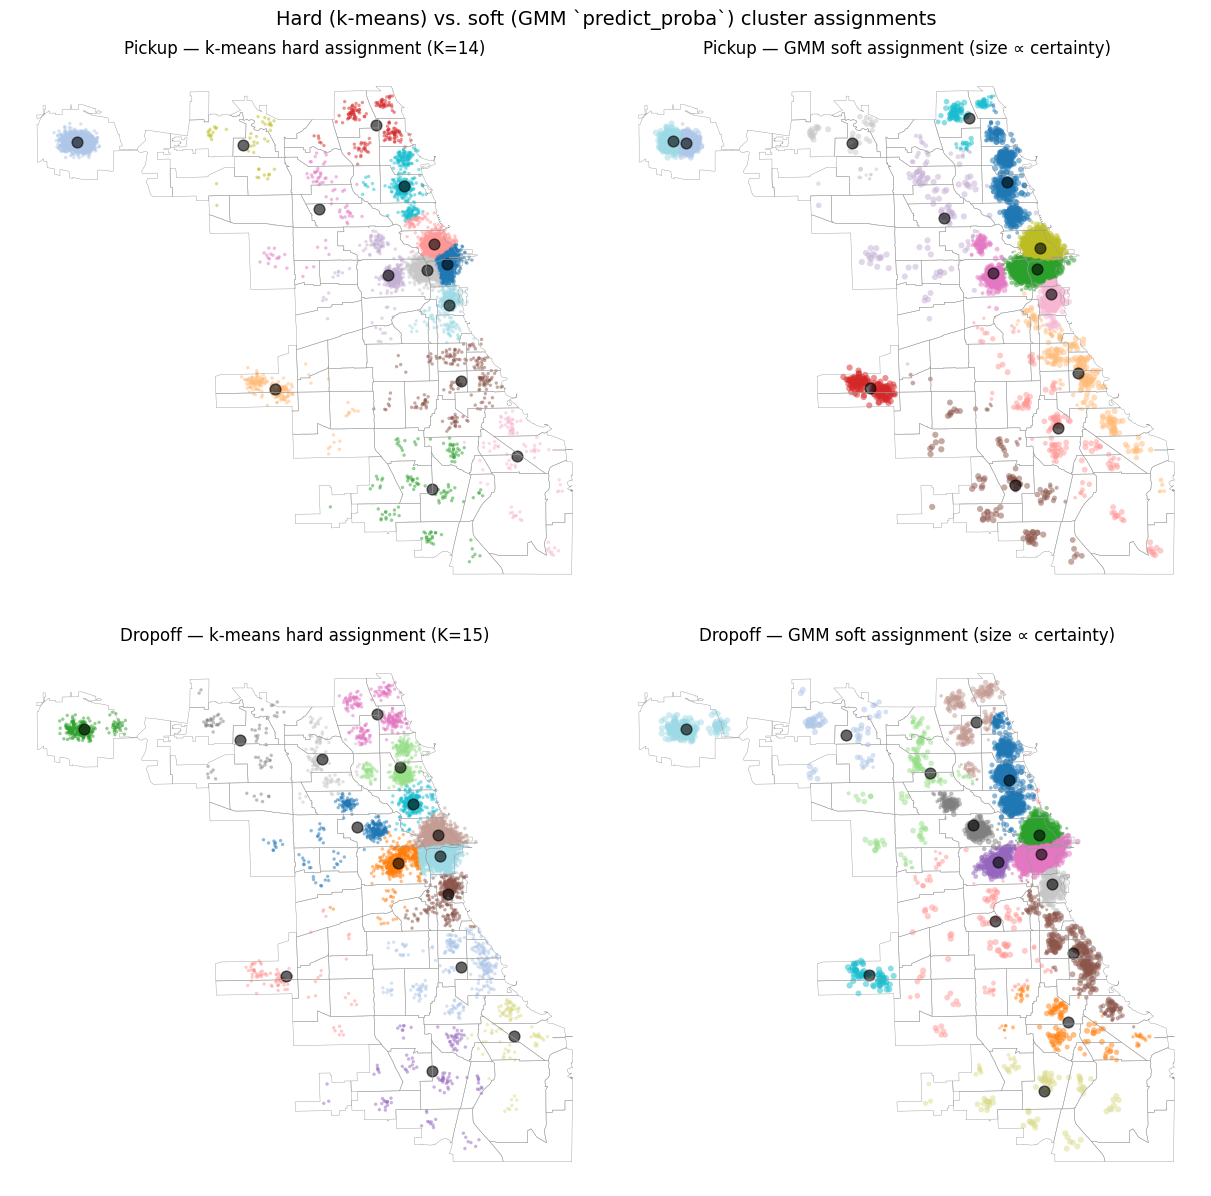

 pickup: 18.1% of points are assigned with < 80% certainty
dropoff: 22.5% of points are assigned with < 80% certainty


In [7]:
N_PLOT = 6_000   # points shown per panel (leading slice of the i.i.d. fitting sample)

kmeans = {side: KMeans(n_clusters=best_k[side], n_init=10,
                       random_state=RANDOM_STATE).fit(samples[side])
          for side in ("pickup", "dropoff")}

# Probabilistic cluster assignments, as in the workshop
probs = {side: gmms[side].predict_proba(samples[side]) for side in ("pickup", "dropoff")}
print("GMM membership probabilities of the first 5 pickup points (columns = components):")
print(probs["pickup"][:5].round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
for row, side in zip(axes, ("pickup", "dropoff")):
    pts = samples[side][:N_PLOT]

    # Left: k-means — every point gets exactly one cluster, centres in black
    km = kmeans[side]
    row[0].scatter(pts[:, 0], pts[:, 1], c=km.labels_[:N_PLOT], s=6,
                   cmap="tab20", alpha=0.5, linewidths=0)
    row[0].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                   c="black", s=60, alpha=0.6)
    row[0].set_title(f"{side.title()} — k-means hard assignment (K={best_k[side]})")

    # Right: GMM — marker size ∝ squared assignment certainty (workshop idiom)
    labels = probs[side][:N_PLOT].argmax(axis=1)
    size = 20 * probs[side][:N_PLOT].max(axis=1) ** 2   # square emphasises differences
    row[1].scatter(pts[:, 0], pts[:, 1], c=labels, s=size,
                   cmap="tab20", alpha=0.5, linewidths=0)
    row[1].scatter(gmms[side].means_[:, 0], gmms[side].means_[:, 1],
                   c="black", s=60, alpha=0.6)
    row[1].set_title(f"{side.title()} — GMM soft assignment (size ∝ certainty)")

    for ax in row:
        communities_gdf.boundary.plot(ax=ax, color="0.6", linewidth=0.3)
        ax.set_aspect("equal")
        ax.set_axis_off()
fig.suptitle("Hard (k-means) vs. soft (GMM `predict_proba`) cluster assignments", fontsize=14)
plt.show()

for side in ("pickup", "dropoff"):
    ambiguous = (probs[side].max(axis=1) < 0.8).mean()
    print(f"{side:>7}: {ambiguous:.1%} of points are assigned with < 80% certainty")

### Mapping the hotspots: components as covariance ellipses

Every component is drawn as a covariance **ellipse** (2σ) centred on its mean — the workshop's `draw_ellipse`/`plot_gmm` idiom — over the community boundaries. The ellipse is shaded by the component **weight** (share of trips), so the most opaque centres are the dominant hotspots.

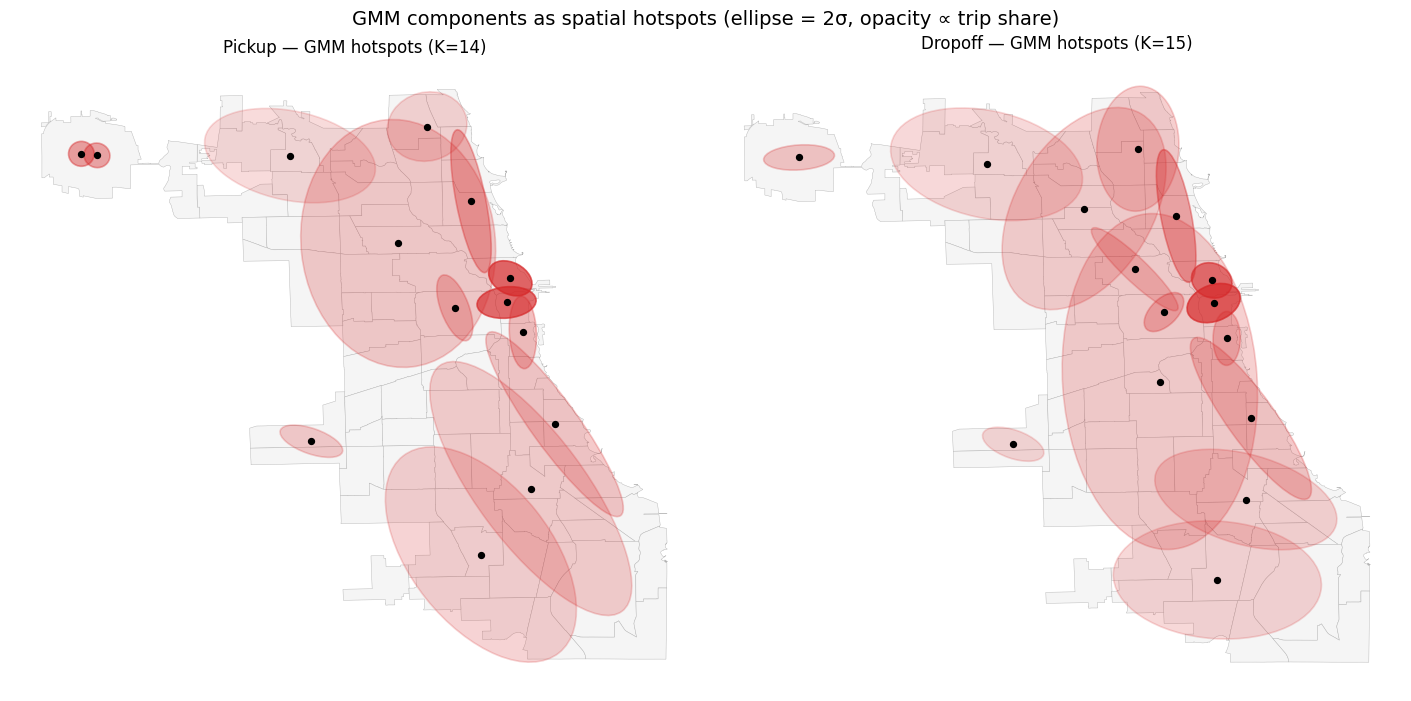

In [8]:
def draw_ellipse(ax, mean, cov, weight, wmax, color):
    """Draw a 2-sigma covariance ellipse, opacity scaled by component weight."""
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * 2 * np.sqrt(vals)   # 2-sigma full axis lengths
    ax.add_patch(Ellipse(mean, width, height, angle=angle,
                         facecolor=color, edgecolor=color,
                         alpha=0.15 + 0.55 * weight / wmax, linewidth=1.2))


fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, side in zip(axes, ("pickup", "dropoff")):
    gm = gmms[side]
    wmax = gm.weights_.max()
    communities_gdf.plot(ax=ax, color="whitesmoke", edgecolor="0.7", linewidth=0.3)
    for mean, cov, weight in zip(gm.means_, gm.covariances_, gm.weights_):
        draw_ellipse(ax, mean, cov, weight, wmax, "tab:red")
    ax.scatter(gm.means_[:, 0], gm.means_[:, 1], s=18, color="black", zorder=5)
    ax.set_title(f"{side.title()} — GMM hotspots (K={best_k[side]})")
    ax.set_aspect("equal")
    ax.set_axis_off()
fig.suptitle("GMM components as spatial hotspots (ellipse = 2σ, opacity ∝ trip share)", fontsize=14)
plt.show()

## 3. Ranked hotspots

Each GMM component mean is located within a community area (point-in-polygon) to give the hotspot a name, then ranked by weight — the estimated share of that side's trips it captures.

In [9]:
def hotspot_table(side):
    gm = gmms[side]
    pts = geopandas.GeoDataFrame(
        {"weight": gm.weights_},
        geometry=geopandas.points_from_xy(gm.means_[:, 0], gm.means_[:, 1]),
        crs="EPSG:4326",
    )
    named = geopandas.sjoin(pts, communities_gdf, predicate="within", how="left")
    named = named.drop_duplicates(subset="geometry")
    out = pd.DataFrame({
        "side": side,
        "community": named["community"].fillna("(outside city)").to_numpy(),
        "lon": gm.means_[:, 0].round(4),
        "lat": gm.means_[:, 1].round(4),
        "trip_share": named["weight"].to_numpy(),
    })
    return out.sort_values("trip_share", ascending=False).reset_index(drop=True)


hotspots = pd.concat([hotspot_table("pickup"), hotspot_table("dropoff")], ignore_index=True)
hotspots["trip_share"] = (hotspots["trip_share"] * 100).round(1).astype(str) + "%"
hotspots

,side,community,lon,lat,trip_share
0,pickup,Near North Side,-87.6286,41.8975,22.2%
1,pickup,Loop,-87.6310,41.8815,21.2%
2,pickup,Ohare,-87.9135,41.9802,11.1%
3,pickup,Ohare,-87.9031,41.9792,10.1%
4,pickup,Lake View,-87.6547,41.9487,8.4%
5,pickup,Near South Side,-87.6202,41.8616,5.7%
6,pickup,Near West Side,-87.6654,41.8779,4.9%
7,pickup,Hyde Park,-87.5992,41.8006,3.7%
8,pickup,Logan Square,-87.7030,41.9207,3.1%
9,pickup,Garfield Ridge,-87.7607,41.7893,3.0%


## Takeaways

- The **KDE** surfaces show where trip density concentrates; for Chicago taxis this is dominated by the **central business district / Loop & Near North** and **O'Hare/Midway airports**.
- The **GMM** reduces that surface to a small set of interpretable hotspots, each with a centre, an extent (the 2σ ellipse) and a **trip share** — the ranked table names the dominant pickup and dropoff hotspots. **AIC** (the workshop's criterion) selects K = 14 for pickups and K = 15 for dropoffs.
- Unlike the **k-means** baseline's hard partition, the GMM is a **soft-clustering** model: `predict_proba` quantifies how certainly each location belongs to a hotspot. Points on the border between two hotspot basins receive split membership instead of an arbitrary hard label — for demand analysis this means border areas contribute to both neighbouring hotspots.
- Because the coordinates are **area centroids**, these hotspots are accurate to community-area resolution, not street level; the KDE bandwidth and GMM jitter encode that uncertainty. Pickups are typically more concentrated (airports + Loop) than dropoffs, which spread further into residential areas.

**Knobs to explore:** `BANDWIDTH` (KDE smoothing), `K_RANGE`/AIC (number of hotspots), and `JITTER`/`SUBSAMPLE` (GMM fitting). Switching the analysis to a projected CRS (e.g. EPSG:3435) would remove the slight lon/lat anisotropy if metric precision is needed.